# ENGI 2001 Engineering Modelling 2

Practical 1 - Python Primer

School of Mathematical Sciences  
February 20, 2026

# Overview

Welcome to Python! You should be familiar with a programming language,
such as Matlab. We will use similar programming concepts, but the syntax
is a little different.

On completion of this practical, you should be able to:

-   Import standard engineering libraries
-   Use Python to do calculations
-   Write functions
-   Manipulate arrays
-   Generate basic plots

> **Tip**
>
> These are transferable skills. Write code whenever you need to do a
> calculation or create a plot. Then you have a record of your work that
> is easy to edit and update and can easily reproduce your results.

This practical is just a primer. You’ll see lots more examples as we
progress through the course.

# 1. Libraries

In Matlab, most mathematical functions are built-in. In Python, we often
need to import libraries for specific tasks. Two libraries that we will
need for this practical (and for many tasks in this course) are:

1.  `numpy`: For arrays and matrices.
2.  `matplotlib`: For plotting graphs.

### Load libraries

Run the following code to import these libraries.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

This syntax imports the required libraries, which can then be referred
to using the aliases `np` and `plt` (instead of typing out the full
name).

# 2. Arithmetic and functions

In this course, we are going to use Python as a sophisticated
calculator.

### Arithmetic operators

The standard assignment and arithmetic operators `=`, `+`, `-`, `*`, `/`
and brackets `()` work as expected for scalars.

> **Note**
>
> Exponentiation in Python is denoted by `**` (not `^`).

For example, compute:
$$
1 - \frac{4^2 + 2}{2 \times 3} 
$$

In [12]:
val = 1 - (4**2 + 2) / (2 * 3)
print("value should be -2: ", val)

value should be -2:  -2.0


> **Tip**
>
> Formulae will be much easier to read if you minimise brackets by using
> operator precedence rules.

### Mathematical functions

`numpy` has a good selection of [standard mathematical
functions](https://numpy.org/doc/stable/reference/routines.math.html).

Since we imported `numpy as np` above, we can access these functions as
`np.function_name`.

For example, to compute $e^{\,\sin(1)}$ run:

In [17]:
val = np.exp(np.sin(1))
print("val: ", val)

val:  2.319776824715853


### User-defined functions

The syntax to define a function is
`def function_name(input arguments):`. The body of the function is
defined by indentation (usually four spaces). There is no `end`. Output
variables are listed after a `return` statement in the body of the
function.

For example, run the following code to define a function called `stress`
that has two input arguments, `force` and `area`, and one output
`sigma`.

In [21]:
def stress(force, area):
    sigma = force / area
    return sigma

You can then use this function by calling it with some actual arguments.
For example, run:

In [23]:
val = stress(100, 2)
print("Stress:", val)

Stress: 50.0


# 3. Arrays

If you enter `a = [0.1, 0.2, 0.3, 0.4, 0.5]` in Python, you will get a
container called a list. Lists are versatile and can contain all sorts
of objects, including numbers, booleans, strings, other lists, etc. For
example:

In [25]:
alist = [10, True, "Alice", [1, 2]]

But lists are not efficient for computation. Instead, we will typically
use `numpy` arrays. Run the following to create an array:

In [27]:
a = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

### Indexing

An individual element of an array can be obtained using an index
enclosed in square brackets.

> **Note**
>
> Python uses zero-based indexing, which means the first element is at
> index `0`, the second element at index `1`, and so on. The last
> element can be accessed using index `-1`.

For example, run:

In [28]:
print("First element:", a[0])
print("Third element:", a[2])
print("Last element:", a[-1])
print("Second-to-last element:", a[-2])

First element: 0.1
Third element: 0.3
Last element: 0.5
Second-to-last element: 0.4


### Slicing

Slicing allows you to grab a subsection of an array. The syntax is
`[start:stop]` for a default step of one, or `[start:stop:step]` is you
want some other step.

> **Note**
>
> `stop` is exclusive, meaning `stop` is the first index *not* included.
> Omitting `start` starts from the first element. Omitting `stop` stops
> at the last element.

For example, run:

In [29]:
print("Second, third and fourth elements:", a[1:4])
print("First, third and fifth elements:", a[0:5:2])
print("First four elements:", a[:4])
print("Last three elements:", a[-3:])

Second, third and fourth elements: [0.2 0.3 0.4]
First, third and fifth elements: [0.1 0.3 0.5]
First four elements: [0.1 0.2 0.3 0.4]
Last three elements: [0.3 0.4 0.5]


### Multidimensional arrays

You can have more than one index. For example, to create the matrix
$$
\begin{bmatrix}
0.1 & 0.2 & 0.3 \\ 0.4 & 0.5 & 0.6 
\end{bmatrix}
$$ run:

In [30]:
A = np.array([
    [0.1, 0.2, 0.3], 
    [0.4, 0.5, 0.6]
])

The first index of `A` corresponds to the row, the second to the column.
You can index and slice as before. For example, run:

In [31]:
print("Second row, second column:", A[1,1])
print("First row, last column:", A[0,-1])
print("All rows, middle column:", A[:,1])
print("All rows, last two columns:\n", A[:,-2:])

Second row, second column: 0.5
First row, last column: 0.3
All rows, middle column: [0.2 0.5]
All rows, last two columns:
 [[0.2 0.3]
 [0.5 0.6]]


### Arithmetic

Arithmetic operators and mathematical functions are applied elementwise
to `numpy` arrays, meaning that the operation is performed on elements
at corresponding positions in each array, resulting in a new array of
the same shape.

> **Note**
>
> Matrix multiplication in Python is denoted by `@` (not `*`).

For example, run:

In [32]:
a = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
b = np.array([0.6, 0.7, 0.8, 0.9, 1.0])
val = a**2 + 2*b + np.cos(a)
print("val:", val)

val: [2.20500417 2.42006658 2.64533649 2.88106099 3.12758256]


# 4. Flow control

### Loops

`for` loops in Python iterate over a sequence. The body of the loop is
again defined by indentation (there is no `end`).

To iterate over indices, you can use `range(n)`, which generates numbers
from `0` to `n-1`:

In [33]:
for i in range(5):
    print(i)

0
1
2
3
4


To iterate over the elements of an array:

In [34]:
arr = np.array([0.1, 0.3, 0.3, 0.4, 0.5])
for elem in arr:
    print(elem)

0.1
0.3
0.3
0.4
0.5


To iterate over both indices and elements of an array:

In [35]:
for i, elem in enumerate(arr):
    print(i, ":", elem)

0 : 0.1
1 : 0.3
2 : 0.3
3 : 0.4
4 : 0.5


### Conditionals

Conditional statements in Python use an `if`, `elif`, `else` structure
(similar to Matlab’s `if`, `elseif`, `else`). The block of code to be
executed in each case is again defined by indentation (there is no
`end`).

> **Note**
>
> Conditional operators `==`, `>`, `<`, `>=` `<=` work as expected. “Not
> equal to” in Python is denoted by `!=`, not `~=`.

For example, run the following code for a few different values of `x` to
see what happens:

In [37]:
x = 10
if x > 5:
    print("x is large")
elif x == 5:
    print("x is five")
else:
    print("x is small")

x is large


# 5. Plotting

Suppose we need to plot $y = x^2 + \ln(x + 1)$ for
$0 \leq x \leq 2 \pi$.

First, use `np.linspace(start, stop, number)` to create evenly spaced
sample points on the given interval by running”

In [38]:
x = np.linspace(0, 2*np.pi, 10)

Next, evaluate the given function at each of those points by running:

In [40]:
y = x**2 + np.log(x + 1)

> **Note**
>
> `np.log()` is the natural logarithm. Use `np.log10()` for $\log_{10}$.

Finally, use `plt.plot(x, y)` to visualize the resulting data by
running:

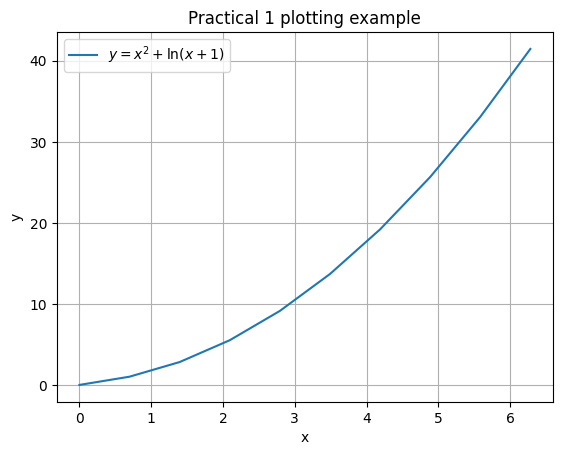

In [41]:
plt.figure()
plt.plot(x, y, '-', label=r'$y = x^2 + \ln(x + 1)$')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Practical 1 plotting example')
plt.legend()
plt.grid()
plt.show()

> **Tips**
>
> -   Always label your axes.
> -   Always provide an informative caption or title.
> -   If plotting more than one curve or data set, include a legend.
> -   If plotting a continuous curve, make sure you used enough points
>     to get a smooth plot.

# 6. Signal noise filtering

Now we will combine these skills (arrays, loops, functions, and
plotting) to solve a common engineering problem: cleaning up a noisy
sensor signal.

### Generate the signal

Create a time array `t` going from 0 to 10 with 100 evenly spaced
points. Create a “true” signal called `y_clean` by evaluating
$y_\text{clean} = e^{-0.2t} \cos(2t)$. Create a “noisy” signal called
`y_noisy` by adding random noise to `y_clean` using
`np.random.normal(0, 0.1, 100)`, which generates random numbers from a
normal distribution with mean 0 and standard deviation 0.1.

In [67]:
# Write your code here
t = np.linspace(0, 10, 100)
y_clean = np.exp(-0.2 * t) * np.cos(2 * t)
y_noisy = y_clean + np.random.normal(0, 0.1, 100)

# print(y_clean)
# print(y_noisy)

### Define a moving-average function

A simple way to smooth noisy data is to apply a moving average. Let
$y_i$ denote noisy data for $i=0,1,\ldots,n-1$, where $n$ is the number
of noisy data points. A moving average for each point $i$ is
$$
\bar{y}_i = \frac{y_{i-1} + y_{i} + y_{i+1}}{3} \quad \text{for $i=1,2,\ldots,n-2$,}
$$ with $\bar{y}_0 = y_0$ and $\bar{y}_{n-1} = y_{n-1}$.

Write a function `moving_average(y)` that:

-   Creates a copy of the noisy input array `y` to store the smoothed
    data in.
-   Determines the number of elements $n$ of `y`.
-   Uses a loop to calculate the smoothed value $\bar{y}_i$ for
    $i=1,2,\ldots,n-2$.
-   Returns the smoothed array.

In [72]:
def moving_average(y):
    # returns the moving average of y
    y_smooth = np.copy(y)
    n = len(y)
    for i in range(1, n - 1): # Add range here
        y_smooth[i] = (y[i-1] + y[i] + y[i + 1]) / 3 # Your code here
    return y_smooth

In [74]:
def moving_average_vec(y):
    # returns the moving average of y
    y_smooth = np.copy(y)
    n = len(y)
    i = np.arange(1, n-1)
    y_smooth[i] = (y[i-1] + y[i] + y[i + 1]) / 3 # Your code here
    return y_smooth

### Smooth data and plot

Apply your function to `y_noisy`. Plot `y_noisy` (as dots) and your new
smoothed signal (as a line) on the same graph.

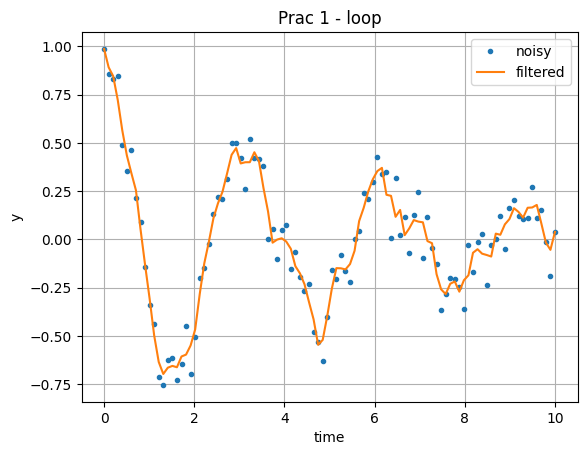

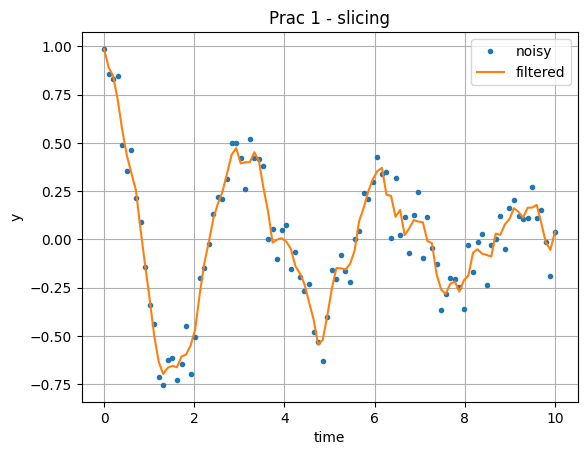

In [76]:
y_smoothed = moving_average(y_noisy)

plt.figure()
plt.plot(t, y_noisy, '.', label="noisy") # Add plot command for noisy data, use `.` for dots
# Add plot command for filtered data, use `-` for lines
plt.plot(t, y_smoothed, '-', label="filtered")
# Add axis labels
plt.xlabel('time')
plt.ylabel('y')
# Add title
plt.title('Prac 1 - loop')
plt.legend()
plt.grid()
plt.show()

y_smoothed_vec = moving_average_vec(y_noisy)

plt.figure()
plt.plot(t, y_noisy, '.', label="noisy") # Add plot command for noisy data, use `.` for dots
# Add plot command for filtered data, use `-` for lines
plt.plot(t, y_smoothed_vec, '-', label="filtered")
# Add axis labels
plt.xlabel('time')
plt.ylabel('y')
# Add title
plt.title('Prac 1 - slicing')
plt.legend()
plt.grid()
plt.show()

### Challenge (Optional)

See if you can implement the formula using slices instead of a loop.